# Modelo de Examen Practico - TLP3 - Python para Ciencia de Datos.


**A partir del datasets brindado, realizar los siguientes procedimientos:**

* Importar datasets con Pandas.
* Explorar los datos con los metodos correspondientes. 
* Limpieza de los datos (Normalización de datos).
* Obtener estadisticas.
* Mostrar los datos procesados con graficos utilizando la libreria Matplotlib.
* Exportar el contenido a un archivo sqlite utilizando PANDAS.


**Importante: Se debe documentar cada procedimiento realizado, siguiendo la siguiente estructura:**

1. Celda de Markdown (Documentación)
2. Código (Sin comentarios, se debe documentar lo sufiente solo en la celda de markdown).

In [1]:
import pandas as pd

df = pd.read_csv("datasets_calificaciones.csv")
df

,estudiante,Materia,Parcial 1,Parcial 2,Final,Asistencia
0,ana pérez,matematicas,8,7.5,9,95%
1,carlos lópez,fisica,6.2,7,NaN,88%
2,maría gómez,quimica,9,8.8,9.5,100%
3,pedro rodríguez,historia,7.5,6,7,75
4,laura vargas,matematicas,,9.2,8.5,92%
...,...,...,...,...,...,...
95,josefina torres,historia,7.4,6.8,7.2,81%
96,bautista vargas,matematicas,8.7,NaN,8.5,92%
97,emma soto,fisica,6.6,7.0,6.4,83%
98,mateo díaz,quimica,9.5,9.7,,98%


# PUNTO 2
## Exploración Inicial del Dataset

### Tipos de Datos de la Tabla
Se verifica el tipo de dato de cada columna para asegurar que coincidan con el contenido esperado.

```python
print(df.dtypes)


In [2]:
print("--------------TIPOS DE DATOS DE LA TABLA----------------")
print(df.dtypes)
print("--------------Cantidad valores nulos----------------")
print(df.isnull().sum())
print("--------------Estadísticas básicas de las columnas----------------")
print(df.describe())
print("-----------------Primeras filas -------------------")
print(df.head())

--------------TIPOS DE DATOS DE LA TABLA----------------
estudiante    object
Materia       object
Parcial 1     object
Parcial 2     object
Final         object
Asistencia    object
dtype: object
--------------Cantidad valores nulos----------------
estudiante     0
Materia        0
Parcial 1      5
Parcial 2     10
Final         11
Asistencia     0
dtype: int64
--------------Estadísticas básicas de las columnas----------------
        estudiante      Materia Parcial 1 Parcial 2 Final Asistencia
count          100          100        95        90    89        100
unique          96            7        49        45    46         35
top     mateo díaz  matematicas                 7.5   9.5        99%
freq             2           25         7         5     4          5
-----------------Primeras filas -------------------
        estudiante      Materia Parcial 1 Parcial 2 Final Asistencia
0        ana pérez  matematicas         8       7.5     9        95%
1     carlos lópez       fisica  

# PUNTO 3
## Conversión de Columnas Numéricas

Para asegurar que las columnas `Parcial 1`, `Parcial 2` y `Final` puedan ser utilizadas en cálculos estadísticos, se las convierte explícitamente a tipo numérico. Cualquier valor que no pueda convertirse será transformado en `NaN` para facilitar su tratamiento posterior (por ejemplo, relleno o eliminación).


In [3]:
df["Parcial 1"] = pd.to_numeric(df["Parcial 1"], errors="coerce")
df["Parcial 2"] = pd.to_numeric(df["Parcial 2"], errors="coerce")
df["Final"] = pd.to_numeric(df["Final"], errors="coerce")

### Relleno de valores nulos y redondeo de notas en un DataFrame

El siguiente código se utiliza para rellenar los valores nulos en las columnas de un DataFrame con la media de cada una de ellas y redondear los valores a dos decimales:



In [4]:
df["Parcial 1"] = df["Parcial 1"].fillna(df["Parcial 1"].mean()).round(2)
df["Parcial 2"] = df["Parcial 2"].fillna(df["Parcial 2"].mean()).round(2)
df["Final"] = df["Final"].fillna(df["Final"].mean()).round(2)


- Muestro las 20 primeras filas para visualizar mis datos y que todo saliera bien

In [5]:
df.head(20)

,estudiante,Materia,Parcial 1,Parcial 2,Final,Asistencia
0,ana pérez,matematicas,8.00,7.50,9.00,95%
1,carlos lópez,fisica,6.20,7.00,7.89,88%
2,maría gómez,quimica,9.00,8.80,9.50,100%
3,pedro rodríguez,historia,7.50,6.00,7.00,75
4,laura vargas,matematicas,7.83,9.20,8.50,92%
5,javier soto,fisica,5.80,6.50,6.00,80%
6,sofia díaz,ciencias sociales,9.50,9.10,7.89,98%
7,miguel fernández,literatura universal,8.00,7.80,8.20,85%
8,valentina ruiz,matematicas,7.00,7.83,7.80,90%
9,diego castro,fisica,6.80,7.20,7.50,93%


- Verifico que ya no se encuentren valores nulos

In [6]:
print(df["Parcial 1"].isnull().sum())
print(df["Parcial 2"].isnull().sum())
print(df["Final"].isnull().sum())

0
0
0


- Convierto la columna asistencia en entero y retiro el string % para luego agregarselo a todas las columnas a las que les faltaba el %
- También noté que habian valores mayores a 100% entonces usé ```clip()``` para forzar a que el máximo de todas sean 100

In [7]:
df["Asistencia"] = df["Asistencia"].str.replace("%", "").astype(int)
df["Asistencia"] = df["Asistencia"].clip(100, upper=True).astype(str) + "%"


In [8]:
df

,estudiante,Materia,Parcial 1,Parcial 2,Final,Asistencia
0,ana pérez,matematicas,8.00,7.50,9.00,95%
1,carlos lópez,fisica,6.20,7.00,7.89,88%
2,maría gómez,quimica,9.00,8.80,9.50,100%
3,pedro rodríguez,historia,7.50,6.00,7.00,75%
4,laura vargas,matematicas,7.83,9.20,8.50,92%
...,...,...,...,...,...,...
95,josefina torres,historia,7.40,6.80,7.20,81%
96,bautista vargas,matematicas,8.70,7.83,8.50,92%
97,emma soto,fisica,6.60,7.00,6.40,83%
98,mateo díaz,quimica,9.50,9.70,7.89,98%


# 4. PUNTO 4
### Estadísticas Descriptivas y Promedio de Notas Finales por Materia

El siguiente código realiza dos operaciones clave sobre un DataFrame: primero, muestra las estadísticas descriptivas de las columnas numéricas y, luego, calcula el promedio de las notas finales agrupadas por materia.

In [9]:
print("----------Estadisticas descriptivas----------")
print(df.describe().round(3))
print("----------Promedio de notas finales por materia----------")
print(df.groupby("Materia")["Final"].mean().round(3))


----------Estadisticas descriptivas----------
       Parcial 1  Parcial 2    Final
count    100.000    100.000  100.000
mean       7.832      7.831    7.893
std        1.134      1.109    1.111
min        5.500      5.800    5.700
25%        7.075      6.975    7.100
50%        7.830      7.830    7.890
75%        8.800      8.800    8.825
max        9.900      9.900    9.900
----------Promedio de notas finales por materia----------
Materia
ciencias sociales       7.890
fisica                  6.625
historia                7.482
literatura universal    8.200
matematicas             8.470
programacion basica     6.300
quimica                 9.027
Name: Final, dtype: float64


# PUNTO 5
### Gráfico de Promedio de Asistencias por Materia

El siguiente código muestra cómo se puede analizar el promedio de asistencias por materia a partir de un DataFrame, y visualizarlos mediante un gráfico de barras utilizando `matplotlib`.

- Creé un nuevo dataframe donde sólo contendría materia y asistencia
- eliminé el string % de las asistencias y lo convertí en entero para hacer cálculos
- Creé otro dataframe donde agruparía el resultado de agrupar el promedio de las asistencias por materia
- Configuré el gráfico de barras para hacer la comparativa


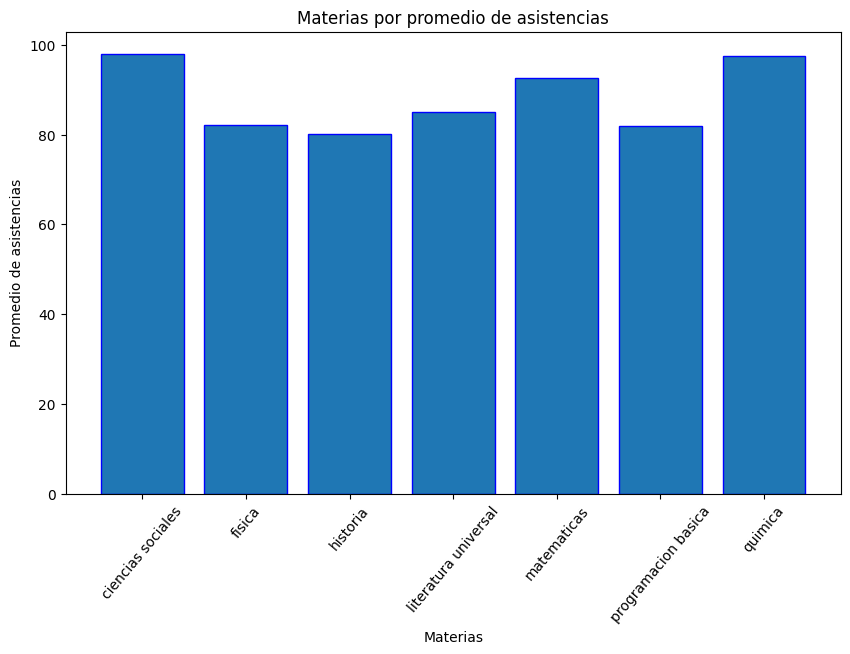

In [10]:
import matplotlib.pyplot as plt

materias_asistencias = df[["Materia", "Asistencia"]].copy() 
materias_asistencias["Asistencia"] = materias_asistencias["Asistencia"].str.replace("%","").astype(int)

agrupadas = materias_asistencias.groupby("Materia")["Asistencia"].mean().round(2)

plt.figure(figsize=(10,6))
plt.title("Materias por promedio de asistencias")
plt.bar(agrupadas.index, agrupadas.values, edgecolor="blue")
plt.xticks(rotation=50)
plt.ylabel("Promedio de asistencias")
plt.xlabel("Materias")
plt.show()



### Histograma de Distribución de Asistencias

El siguiente código genera un histograma para visualizar la distribución de asistencias de los estudiantes en base a la columna "Asistencia" de un DataFrame.



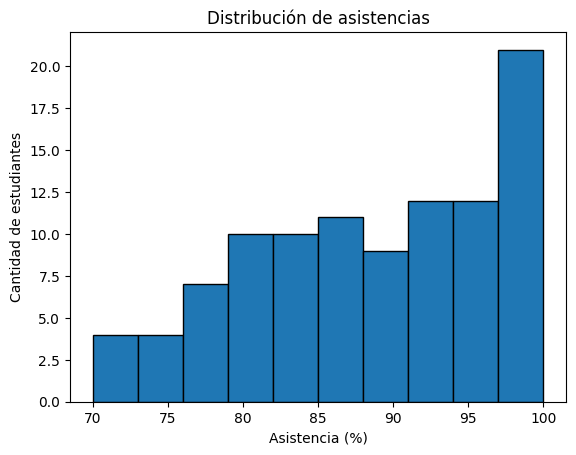

In [11]:
plt.hist(materias_asistencias["Asistencia"], bins=10, edgecolor="black")
plt.title("Distribución de asistencias")
plt.xlabel("Asistencia (%)")
plt.ylabel("Cantidad de estudiantes")
plt.show()


### PUNTO 6
### Guardar un DataFrame en una Base de Datos SQLite

El siguiente código muestra cómo guardar un DataFrame en una base de datos SQLite utilizando `SQLAlchemy` y el método `to_sql` de pandas.

- Para hacer esto instalé la dependencia sqlalchemy e importé create_engie para luego definir una ruta con el nombre de mi nueva tabla y su extensión que luego fue pasada como parámetro


In [12]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///notas.sqlite")

df.to_sql("notas", con=engine, index=False, if_exists="replace")


100